In [1]:
import os 
import numpy as np
import torch 
import matplotlib.pyplot as plt
import pandas as pd

Mean Pearson r by condition and split (means are across coordinates and reps):
split                                adv   train     val
condition                                               
diet_smallnorb_model_cnn_crop     0.4687  0.6926  0.6982
diet_smallnorb_model_cnn_none     0.5438  0.5653  0.5555
diet_smallnorb_model_cnn_simclr   0.4226  0.6564  0.6901
diet_smallnorb_model_cnn_simclr2  0.4269  0.5957  0.6602
diet_smallnorb_model_cnn_sup      0.4507  0.6719  0.6761
diet_smallnorb_model_cnn_sup2     0.3876  0.6565  0.6594


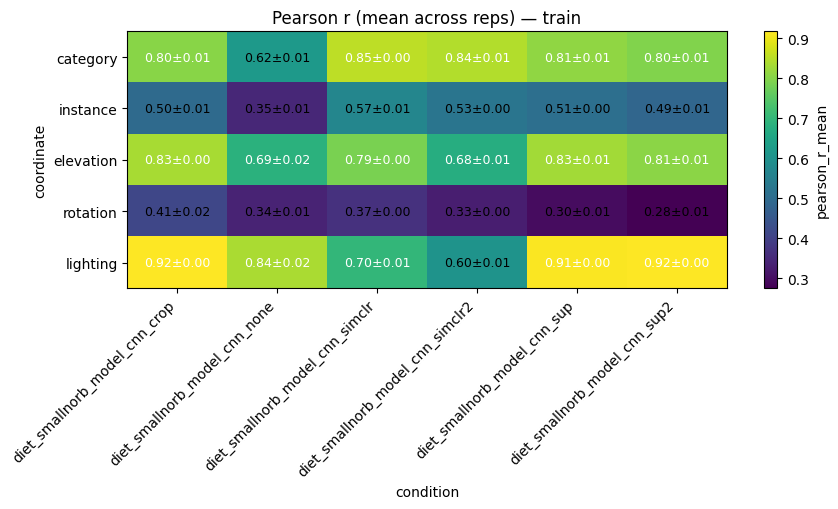

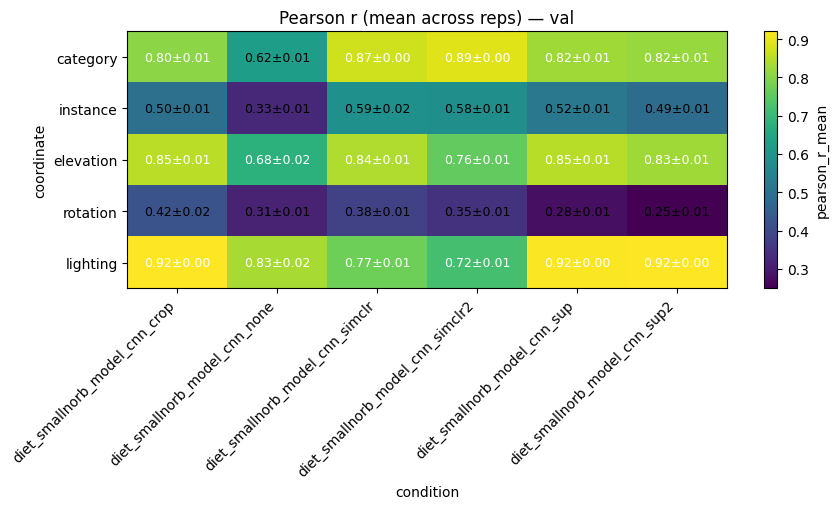

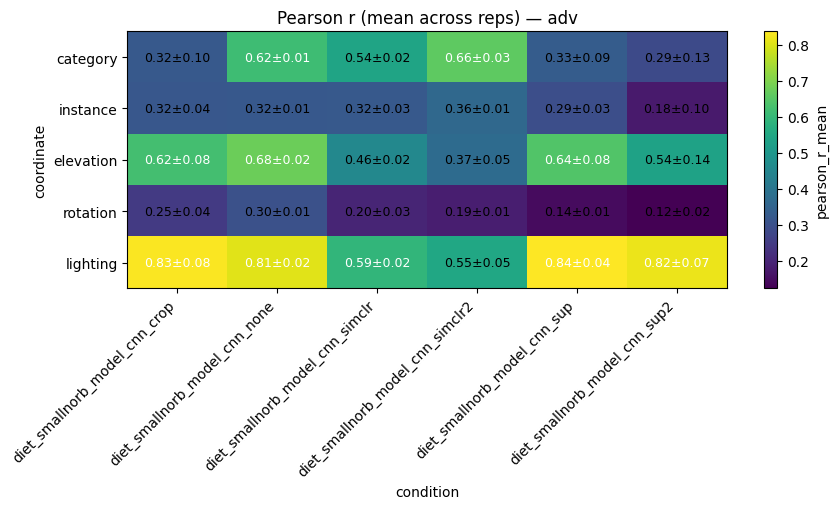

In [2]:
ds = "smallnorb"
from __future__ import annotations

import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Config
# -----------------------------
ROOT = Path(".")                   # change if needed
GLOB_PATTERN = f"**/logs_2/*{ds}*/identifiability.txt"
ANNOTATE_STYLE = "mean±std"        # "mean" or "mean±std"
TEXT_DECIMALS = 2

# -----------------------------
# Regex parsers (match your log format)
# -----------------------------
COORD_RE = re.compile(r"^Coordinate\s+(\d+)\s+(.+?)\s*$")
SPLIT_RE = re.compile(
    r"^(train|val|adv)\s+PearsonRResult\("
    r"statistic=np\.float64\(([-+0-9.eE]+)\),\s*"
    r"pvalue=np\.float64\(([-+0-9.eE]+)\)\)"
)
REP_RE = re.compile(r"^(?P<condition>.+?)_rep_(?P<rep>\d+)$")


def parse_identifiability_file(path: Path) -> list[dict]:
    rows: list[dict] = []
    current_coord_idx = None
    current_coord_name = None

    experiment = path.parent.name  # folder name holding identifiability.txt

    with path.open("r", encoding="utf-8", errors="ignore") as f:
        for raw in f:
            line = raw.strip()
            if not line:
                continue

            m_coord = COORD_RE.match(line)
            if m_coord:
                current_coord_idx = int(m_coord.group(1))
                current_coord_name = m_coord.group(2).strip()
                continue

            m_split = SPLIT_RE.match(line)
            if m_split and current_coord_idx is not None:
                split = m_split.group(1)
                statistic = float(m_split.group(2))
                pvalue = float(m_split.group(3))
                rows.append(
                    dict(
                        experiment=experiment,
                        file=str(path),
                        coordinate_idx=current_coord_idx,
                        coordinate=current_coord_name,
                        split=split,
                        pearson_r=statistic,
                        pvalue=pvalue,
                    )
                )

    return rows


def parse_all(root: Path, pattern: str) -> pd.DataFrame:
    files = sorted(root.glob(pattern))
    if not files:
        raise FileNotFoundError(f"No files found under {root} matching: {pattern}")

    all_rows: list[dict] = []
    for p in files:
        all_rows.extend(parse_identifiability_file(p))

    df = pd.DataFrame(all_rows)
    if df.empty:
        raise ValueError("Parsed zero rows. Check regexes vs your log format.")
    return df


def add_condition_and_rep(df: pd.DataFrame) -> pd.DataFrame:
    m = df["experiment"].str.extract(REP_RE)
    out = df.copy()
    out["condition"] = m["condition"].fillna(out["experiment"])
    out["rep"] = pd.to_numeric(m["rep"], errors="coerce")
    return out


def aggregate_across_reps(df: pd.DataFrame) -> pd.DataFrame:
    agg = (
        df.groupby(["condition", "split", "coordinate_idx", "coordinate"], as_index=False)
          .agg(
              pearson_r_mean=("pearson_r", "mean"),
              pearson_r_std=("pearson_r", "std"),
              n=("pearson_r", "count"),
          )
    )
    # std is NaN when n=1
    agg["pearson_r_std"] = agg["pearson_r_std"].fillna(0.0)
    return agg


# -----------------------------
# Plotting
# -----------------------------
def _coord_order(agg: pd.DataFrame) -> list[str]:
    return (
        agg[["coordinate_idx", "coordinate"]]
        .drop_duplicates()
        .sort_values("coordinate_idx")["coordinate"]
        .tolist()
    )

def plot_heatmap_annotated(
    agg: pd.DataFrame,
    split: str,
    annotate: str = "mean±std",
    decimals: int = 2,
):
    """
    Heatmap: coordinates (rows) x conditions (cols)
    Values: mean across reps for the requested split, with numeric annotations.
    """
    sub = agg[agg["split"] == split].copy()
    if sub.empty:
        raise ValueError(f"No rows for split={split}")

    coord_order = _coord_order(agg)

    mean_p = sub.pivot_table(index="coordinate", columns="condition", values="pearson_r_mean", aggfunc="mean")
    std_p  = sub.pivot_table(index="coordinate", columns="condition", values="pearson_r_std",  aggfunc="mean")

    mean_p = mean_p.reindex(coord_order)
    std_p = std_p.reindex(coord_order)

    # Sort conditions alphabetically (change if you want custom ordering)
    mean_p = mean_p.reindex(sorted(mean_p.columns), axis=1)
    std_p = std_p.reindex(mean_p.columns, axis=1)

    data = mean_p.to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(max(9, 0.6 * mean_p.shape[1]), 5.2))
    im = ax.imshow(data, aspect="auto")

    ax.set_title(f"Pearson r (mean across reps) — {split}")
    ax.set_xlabel("condition")
    ax.set_ylabel("coordinate")

    ax.set_xticks(range(mean_p.shape[1]))
    ax.set_xticklabels(mean_p.columns, rotation=45, ha="right")
    ax.set_yticks(range(mean_p.shape[0]))
    ax.set_yticklabels(mean_p.index)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("pearson_r_mean")

    # Contrast heuristic for text color
    finite = data[np.isfinite(data)]
    vmin = float(np.min(finite)) if finite.size else 0.0
    vmax = float(np.max(finite)) if finite.size else 1.0
    denom = (vmax - vmin) if (vmax - vmin) != 0 else 1.0

    for i in range(mean_p.shape[0]):
        for j in range(mean_p.shape[1]):
            mean_val = mean_p.iat[i, j]
            std_val = std_p.iat[i, j]
            if pd.isna(mean_val):
                continue

            if annotate == "mean±std":
                text = f"{mean_val:.{decimals}f}±{std_val:.{decimals}f}"
            else:
                text = f"{mean_val:.{decimals}f}"

            norm = (mean_val - vmin) / denom
            color = "white" if norm > 0.60 else "black"

            ax.text(j, i, text, ha="center", va="center", fontsize=9, color=color)

    fig.tight_layout()
    plt.show()


def plot_grouped_bars_by_coordinate(agg: pd.DataFrame):
    """
    For each coordinate, plot grouped bars (train/val/adv) per condition.
    Error bars show std across reps.
    """
    coords = _coord_order(agg)
    splits = ["train", "val", "adv"]

    for coord in coords:
        sub = agg[agg["coordinate"] == coord].copy()
        if sub.empty:
            continue

        mean_p = sub.pivot_table(index="condition", columns="split", values="pearson_r_mean", aggfunc="mean")
        std_p  = sub.pivot_table(index="condition", columns="split", values="pearson_r_std",  aggfunc="mean")

        mean_p = mean_p.reindex(sorted(mean_p.index))
        std_p = std_p.reindex(mean_p.index)

        mean_p = mean_p.reindex(columns=[s for s in splits if s in mean_p.columns])
        std_p = std_p.reindex(columns=mean_p.columns)

        ax = mean_p.plot(kind="bar", figsize=(max(10, 0.6 * len(mean_p.index)), 4.8), yerr=std_p)
        ax.set_title(f"Pearson r (mean±std across reps) — {coord}")
        ax.set_ylabel("pearson_r")
        ax.set_xlabel("condition")
        ax.legend(title="split")
        plt.tight_layout()
        plt.show()


def plot_lines_per_condition(agg: pd.DataFrame, split: str = "adv"):
    """
    For each condition, plot a line across coordinates for a chosen split (often 'adv').
    Values are means across reps.
    """
    coords = _coord_order(agg)
    conditions = sorted(agg["condition"].unique())

    for cond in conditions:
        sub = agg[(agg["condition"] == cond) & (agg["split"] == split)].copy()
        if sub.empty:
            continue

        sub = sub.set_index("coordinate").reindex(coords)
        y = sub["pearson_r_mean"].to_numpy(dtype=float)

        fig, ax = plt.subplots(figsize=(7.6, 4.2))
        ax.plot(coords, y, marker="o")
        ax.set_title(f"{cond} — Pearson r across coordinates ({split}, mean across reps)")
        ax.set_ylabel("pearson_r_mean")
        ax.set_xlabel("coordinate")
        ax.set_ylim(0.0, 1.0)
        ax.tick_params(axis="x", rotation=30)
        fig.tight_layout()
        plt.show()


# -----------------------------
# Run everything
# -----------------------------
df_raw = parse_all(ROOT, GLOB_PATTERN)
df_raw = add_condition_and_rep(df_raw)
agg = aggregate_across_reps(df_raw)

# Optional: quick summary table in console
summary = (
    agg.groupby(["condition", "split"], as_index=False)["pearson_r_mean"].mean()
       .pivot(index="condition", columns="split", values="pearson_r_mean")
       .sort_index()
)
print("Mean Pearson r by condition and split (means are across coordinates and reps):")
print(summary.round(4).to_string())

# Heatmaps with numbers
for sp in ["train", "val", "adv"]:
    plot_heatmap_annotated(agg, sp, annotate=ANNOTATE_STYLE, decimals=TEXT_DECIMALS)

# Bars (one figure per coordinate)
#plot_grouped_bars_by_coordinate(agg)

# Lines (one figure per condition) for adv by default
#plot_lines_per_condition(agg, split="adv")


In [3]:
# geom > sup > crop > none  : shape
experiments = np.unique(agg.condition)
print(experiments)

for experiment in experiments:
    agg_ = agg[agg.condition == experiment].copy()
    
    print(experiment, 
          np.mean(agg_[(agg_.split == 'val') & 
              ((agg_.coordinate_idx > 0)   )].iloc[:, 4]))


['diet_smallnorb_model_cnn_crop' 'diet_smallnorb_model_cnn_none'
 'diet_smallnorb_model_cnn_simclr' 'diet_smallnorb_model_cnn_simclr2'
 'diet_smallnorb_model_cnn_sup' 'diet_smallnorb_model_cnn_sup2']
diet_smallnorb_model_cnn_crop 0.6717719940047524
diet_smallnorb_model_cnn_none 0.5386402151464077
diet_smallnorb_model_cnn_simclr 0.6446722858806734
diet_smallnorb_model_cnn_simclr2 0.6033214136057258
diet_smallnorb_model_cnn_sup 0.6392222127214046
diet_smallnorb_model_cnn_sup2 0.6201661145078828


In [4]:
ds = 'smallnorb'
experiments = [
    f"diet_{ds}_model_cnn_none",
    f"diet_{ds}_model_cnn_crop",
    f"diet_{ds}_model_cnn_sup",
    f"diet_{ds}_model_cnn_sup2",
    f"diet_{ds}_model_cnn_simclr2"
]


pearson_r_mean
pearson_r_mean
pearson_r_mean
pearson_r_mean
pearson_r_mean
Across-experiment STD: ident: 0.049504960206502836 acc: 0.1789785709310571 adv: 0.09946678751803378 rob: 0.27818876676821774


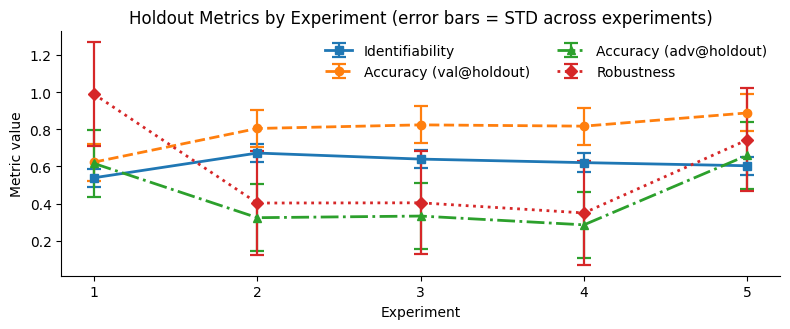

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# --- X axis ---
x_dict = {"smallnorb": [1, 2, 3, 4, 5]}
x = np.arange(len(experiments))

# --- Collect one point per experiment (as you already do) ---
ident, acc, adv, rob = [], [], [], []

def nanstd(vec):
    v = np.asarray(vec, dtype=float)
    v = v[~np.isnan(v)]
    if v.size <= 1:
        return np.nan
    return np.nanstd(v, ddof=1)

for experiment in experiments:
    agg_ = agg[agg.condition == experiment]
    metric_col = agg_.columns[4]
    print(metric_col)
    id_series  = agg_.loc[(agg_.split == 'val') & (agg_.coordinate_idx != 0), metric_col]
    val_series = agg_.loc[(agg_.split == 'val') & (agg_.coordinate_idx == 0),  metric_col]
    adv_series = agg_.loc[(agg_.split == 'adv') & (agg_.coordinate_idx == 0),  metric_col]

    # Point estimates per experiment
    ident.append(id_series.mean())
    adv.append(val_series.mean())   # "Accuracy (val@holdout)" in your legend
    acc.append(adv_series.mean())   # "Accuracy (adv@holdout)" in your legend

    # Robustness per experiment
    v = val_series.to_numpy(dtype=float)
    a = adv_series.to_numpy(dtype=float)
    n = min(len(v), len(a))
    if n == 0:
        rob.append(np.nan)
    else:
        v = v[:n]
        a = a[:n]
        v_safe = np.where(v == 0, np.nan, v)
        rob_vals = 1 - ((v - a) / v_safe)
        rob.append(np.nanmean(rob_vals))

# --- Compute STD across experiments (global) and apply as constant error bars ---
ident_std = nanstd(ident)
acc_std   = nanstd(acc)
adv_std   = nanstd(adv)
rob_std   = nanstd(rob)

ident_yerr = np.full(len(x), ident_std, dtype=float)
acc_yerr   = np.full(len(x), acc_std,   dtype=float)
adv_yerr   = np.full(len(x), adv_std,   dtype=float)
rob_yerr   = np.full(len(x), rob_std,   dtype=float)

print("Across-experiment STD:",
      "ident:", ident_std, "acc:", acc_std, "adv:", adv_std, "rob:", rob_std)

# --- Plot: different style per series for readability ---
fig, ax = plt.subplots(figsize=(8, 3.4))

series = [
    ("Identifiability",            ident, ident_yerr, dict(fmt='s-',  linewidth=2, markersize=6)),
    ("Accuracy (val@holdout)",     adv,   adv_yerr,   dict(fmt='o--', linewidth=2, markersize=6)),
    ("Accuracy (adv@holdout)",     acc,   acc_yerr,   dict(fmt='^-.' ,linewidth=2, markersize=6)),
    ("Robustness",                 rob,   rob_yerr,   dict(fmt='D:',  linewidth=2, markersize=6)),
]

for label, y, yerr, sty in series:
    ax.errorbar(
        x, y, yerr=yerr,
        capsize=5, capthick=1.6, elinewidth=1.6,
        label=label,
        **sty
    )

ax.set_xticks(x)
ax.set_xticklabels(x_dict[ds], rotation=0)
ax.set_xlabel("Experiment")
ax.set_ylabel("Metric value")
ax.set_title("Holdout Metrics by Experiment (error bars = STD across experiments)")
ax.legend(ncol=2, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


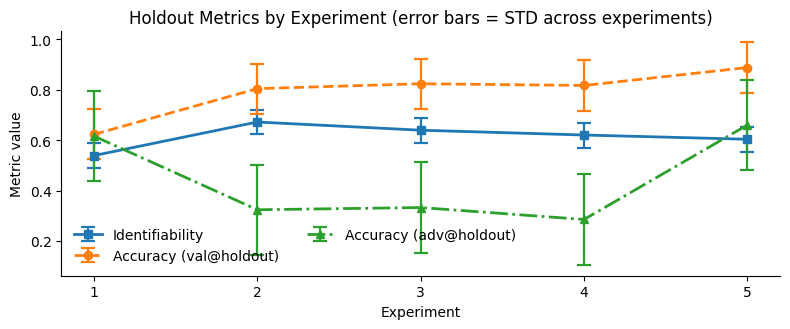

In [17]:
# --- Plot: different style per series for readability ---
fig, ax = plt.subplots(figsize=(8, 3.4))

series = [
    ("Identifiability",            ident, ident_yerr, dict(fmt='s-',  linewidth=2, markersize=6)),
    ("Accuracy (val@holdout)",     adv,   adv_yerr,   dict(fmt='o--', linewidth=2, markersize=6)),
    ("Accuracy (adv@holdout)",     acc,   acc_yerr,   dict(fmt='^-.' ,linewidth=2, markersize=6)),
    #("Robustness",                 rob,   rob_yerr,   dict(fmt='D:',  linewidth=2, markersize=6)),
]

for label, y, yerr, sty in series:
    ax.errorbar(
        x, y, yerr=yerr,
        capsize=5, capthick=1.6, elinewidth=1.6,
        label=label,
        **sty
    )

ax.set_xticks(x)
ax.set_xticklabels(x_dict[ds], rotation=0)
ax.set_xlabel("Experiment")
ax.set_ylabel("Metric value")
ax.set_title("Holdout Metrics by Experiment (error bars = STD across experiments)")
ax.legend(ncol=2, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

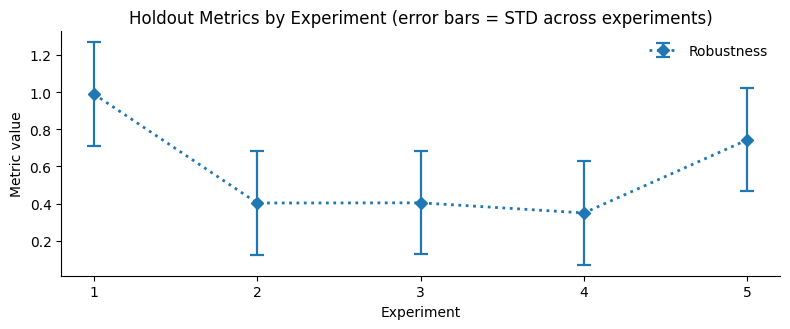

In [18]:
# --- Plot: different style per series for readability ---
fig, ax = plt.subplots(figsize=(8, 3.4))

series = [
    #("Identifiability",            ident, ident_yerr, dict(fmt='s-',  linewidth=2, markersize=6)),
    #("Accuracy (val@holdout)",     adv,   adv_yerr,   dict(fmt='o--', linewidth=2, markersize=6)),
    # ("Accuracy (adv@holdout)",     acc,   acc_yerr,   dict(fmt='^-.' ,linewidth=2, markersize=6)),
    ("Robustness",                 rob,   rob_yerr,   dict(fmt='D:',  linewidth=2, markersize=6)),
]

for label, y, yerr, sty in series:
    ax.errorbar(
        x, y, yerr=yerr,
        capsize=5, capthick=1.6, elinewidth=1.6,
        label=label,
        **sty
    )

ax.set_xticks(x)
ax.set_xticklabels(x_dict[ds], rotation=0)
ax.set_xlabel("Experiment")
ax.set_ylabel("Metric value")
ax.set_title("Holdout Metrics by Experiment (error bars = STD across experiments)")
ax.legend(ncol=2, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()